<a href="https://colab.research.google.com/github/VidushiSharma31/Multi-Class-Breast-Cancer-Classification/blob/main/breast_cancer_resnet18.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import json
import os

kaggle_creds = {
    "username": "vidushisharma1011",
    "key": "KGAT_8ff113537964c4de942056d2b69ed6de"
}

os.makedirs("/root/.kaggle", exist_ok=True)

with open("/root/.kaggle/kaggle.json", "w") as f:
    json.dump(kaggle_creds, f)


In [ ]:
!chmod 600 /root/.kaggle/kaggle.json

chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [ ]:
!kaggle datasets download -d ambarish/breakhis
!unzip breakhis.zip

Streaming output truncated to the last 5000 lines.
  inflating: BreaKHis_v1/BreaKHis_v1/histology_slides/breast/malignant/SOB/ductal_carcinoma/SOB_M_DC_14-12312/40X/SOB_M_DC-14-12312-40-026.png  
  inflating: BreaKHis_v1/BreaKHis_v1/histology_slides/breast/malignant/SOB/ductal_carcinoma/SOB_M_DC_14-12312/40X/SOB_M_DC-14-12312-40-027.png  
  inflating: BreaKHis_v1/BreaKHis_v1/histology_slides/breast/malignant/SOB/ductal_carcinoma/SOB_M_DC_14-12312/40X/SOB_M_DC-14-12312-40-028.png  
  inflating: BreaKHis_v1/BreaKHis_v1/histology_slides/breast/malignant/SOB/ductal_carcinoma/SOB_M_DC_14-12312/40X/SOB_M_DC-14-12312-40-029.png  
  inflating: BreaKHis_v1/BreaKHis_v1/histology_slides/breast/malignant/SOB/ductal_carcinoma/SOB_M_DC_14-12312/40X/SOB_M_DC-14-12312-40-030.png  
  inflating: BreaKHis_v1/BreaKHis_v1/histology_slides/breast/malignant/SOB/ductal_carcinoma/SOB_M_DC_14-12312/40X/SOB_M_DC-14-12312-40-031.png  
  inflating: BreaKHis_v1/BreaKHis_v1/histology_slides/breast/malignant/SOB/duct

In [ ]:
import os
import shutil
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import Subset
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [ ]:
np.random.seed(42)
torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [ ]:
src_root = "BreaKHis_v1/BreaKHis_v1/histology_slides/breast"
dst_root = "breakhis_multiclass"

os.makedirs(dst_root, exist_ok=True)

In [ ]:
for group in ["benign", "malignant"]:
    group_path = os.path.join(src_root, group, "SOB")

    for cls in os.listdir(group_path):
        cls_path = os.path.join(group_path, cls)

        # one folder per class (8 total)
        dst_cls = os.path.join(dst_root, cls)
        os.makedirs(dst_cls, exist_ok=True)

        for case in os.listdir(cls_path):
            case_path = os.path.join(cls_path, case)

            for mag in os.listdir(case_path):
                if mag != "40X":
                    continue

                mag_path = os.path.join(case_path, mag)

                for img in os.listdir(mag_path):
                    if img.lower().endswith((".png", ".jpg", ".jpeg")):
                        new_name = f"{cls}_{case}_{img}"

                        shutil.copy(
                            os.path.join(mag_path, img),
                            os.path.join(dst_cls, new_name)
                        )

print("40X dataset for all 8 classes created successfully!")


40X dataset for all 8 classes created successfully!


In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

In [ ]:
data_dir = dst_root
full_dataset = datasets.ImageFolder(root=data_dir)
num_classes = len(full_dataset.classes)
num_samples = len(full_dataset)
indices = np.random.permutation(num_samples)

train_size = int(0.8 * num_samples)
train_idx, val_idx = indices[:train_size], indices[train_size:]

train_dataset = Subset(datasets.ImageFolder(root=data_dir, transform=train_transform), train_idx)
val_dataset   = Subset(datasets.ImageFolder(root=data_dir, transform=val_transform), val_idx)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2, pin_memory=True)

print(f"Total images: {num_samples}, Train: {len(train_dataset)}, Val: {len(val_dataset)}")
print("Classes:", full_dataset.classes)
print("Num classes:", num_classes)

Total images: 1995, Train: 1596, Val: 399
Classes: ['adenosis', 'ductal_carcinoma', 'fibroadenoma', 'lobular_carcinoma', 'mucinous_carcinoma', 'papillary_carcinoma', 'phyllodes_tumor', 'tubular_adenoma']
Num classes: 8


In [ ]:
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 191MB/s]


In [ ]:
num_epochs = 10
train_losses = []
val_losses = []
train_accs = []
val_accs = []

In [ ]:
for epoch in range(num_epochs):
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        train_correct += (outputs.argmax(1) == labels).sum().item()
        train_total += labels.size(0)

    train_loss /= train_total
    train_acc = 100.0 * train_correct / train_total

    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            val_correct += (outputs.argmax(1) == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = 100.0 * val_correct / val_total

    print(f"Epoch [{epoch+1:02d}/{num_epochs}] | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% || "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

Epoch [01/10] | Train Loss: 1.1588 | Train Acc: 60.15% || Val Loss: 0.7304 | Val Acc: 73.18%
Epoch [02/10] | Train Loss: 0.4377 | Train Acc: 86.15% || Val Loss: 0.3881 | Val Acc: 85.96%
Epoch [03/10] | Train Loss: 0.2604 | Train Acc: 92.29% || Val Loss: 0.2913 | Val Acc: 90.48%
Epoch [04/10] | Train Loss: 0.1650 | Train Acc: 95.80% || Val Loss: 0.2857 | Val Acc: 90.48%
Epoch [05/10] | Train Loss: 0.1416 | Train Acc: 94.92% || Val Loss: 0.2697 | Val Acc: 89.47%
Epoch [06/10] | Train Loss: 0.1356 | Train Acc: 95.74% || Val Loss: 0.3201 | Val Acc: 87.72%
Epoch [07/10] | Train Loss: 0.0889 | Train Acc: 96.99% || Val Loss: 0.2583 | Val Acc: 91.73%
Epoch [08/10] | Train Loss: 0.0712 | Train Acc: 97.56% || Val Loss: 0.2113 | Val Acc: 91.23%
Epoch [09/10] | Train Loss: 0.0784 | Train Acc: 97.18% || Val Loss: 0.2209 | Val Acc: 91.98%
Epoch [10/10] | Train Loss: 0.0635 | Train Acc: 97.93% || Val Loss: 0.2262 | Val Acc: 91.98%


In [ ]:
model.eval()

y_true, y_pred = [], []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

acc  = accuracy_score(y_true, y_pred) * 100
prec = precision_score(y_true, y_pred, average="macro") * 100
rec  = recall_score(y_true, y_pred, average="macro") * 100
f1   = f1_score(y_true, y_pred, average="macro") * 100

print("\nVALIDATION METRICS (MULTI-CLASS)")
print(f"Accuracy : {acc:.2f}%")
print(f"Precision: {prec:.2f}%")
print(f"Recall   : {rec:.2f}%")
print(f"F1-score : {f1:.2f}%")


VALIDATION METRICS (MULTI-CLASS)
Accuracy : 91.98%
Precision: 92.01%
Recall   : 91.49%
F1-score : 91.48%


                     precision    recall  f1-score   support

           adenosis       0.95      1.00      0.97        18
   ductal_carcinoma       0.93      0.92      0.93       161
       fibroadenoma       0.88      1.00      0.93        49
  lobular_carcinoma       0.78      0.72      0.75        29
 mucinous_carcinoma       0.92      0.94      0.93        49
papillary_carcinoma       0.94      0.97      0.96        34
    phyllodes_tumor       1.00      0.77      0.87        30
    tubular_adenoma       0.97      1.00      0.98        29

           accuracy                           0.92       399
          macro avg       0.92      0.91      0.91       399
       weighted avg       0.92      0.92      0.92       399



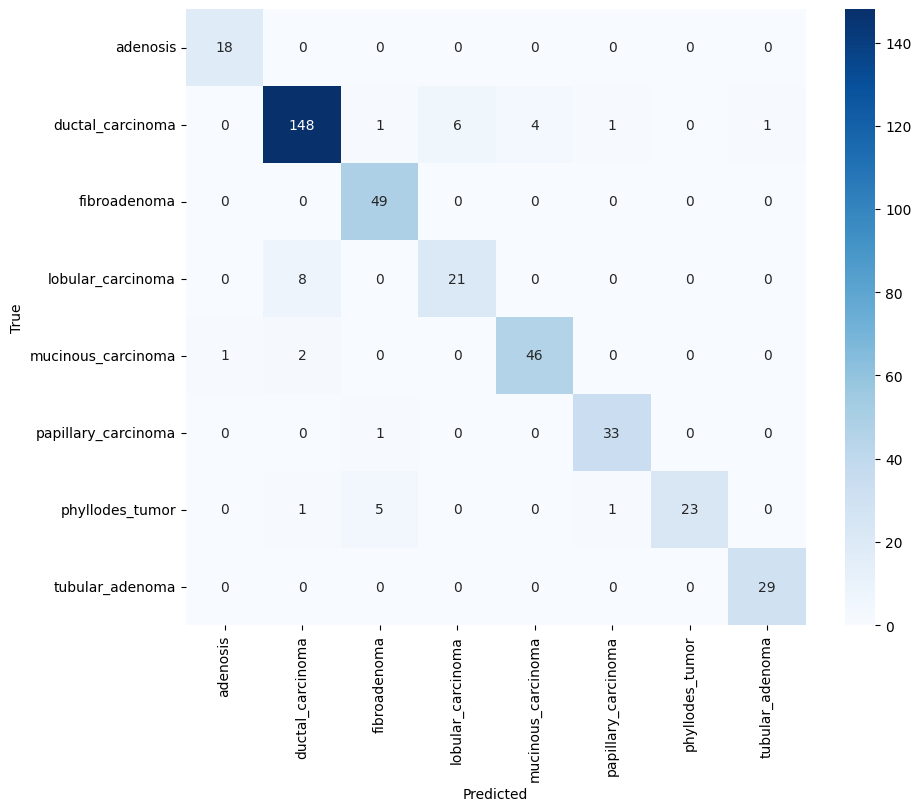

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)
class_names = full_dataset.classes
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')

print(classification_report(y_true, y_pred, target_names=class_names))

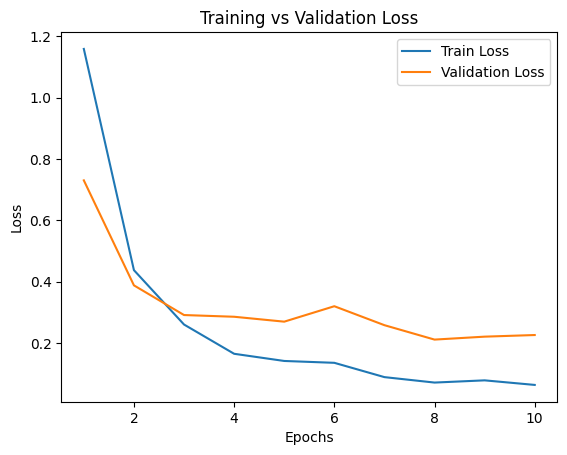

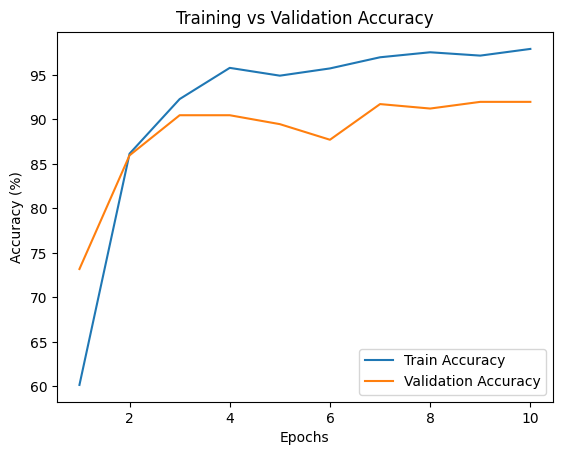

In [ ]:
epochs = range(1, num_epochs + 1)

# Loss plot
plt.figure()
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

# Accuracy plot
plt.figure()
plt.plot(epochs, train_accs, label="Train Accuracy")
plt.plot(epochs, val_accs, label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()


In [ ]:
torch.save(model.state_dict(), "resnet18_breakhis.pth")